##CONFIGURATION ENVIRONNEMENT

In [ ]:
import os
import heapq
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras import backend as K
from matplotlib.colors import ListedColormap
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import plot_model
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import Callback
from tensorflow.keras.initializers import HeNormal
from sklearn.model_selection import train_test_split
from tensorflow.keras.layers import ConvLSTM2D, MaxPooling3D, Conv2D, UpSampling2D

##IMPORT DES DONNEES

In [ ]:
# Dossier contenant les fichiers .npy
data_folder = [os.path.join('..', 'data', 'dataset_convlstm')]

# Fonction pour extraire les images et les années à partir du nom de fichier
def load_images_with_years(data_folder):
    images = []
    years = []

    # Charger les images pour chaque année en fonction des noms de fichiers
    for file_name in os.listdir(data_folder):
        if file_name.endswith(".tif.npy"):  # Assurer que ce soit bien un fichier .npy
            year = int(file_name.split('_')[-1].split('.')[0])  # Extraire l'année du nom de fichier
            image_path = os.path.join(data_folder, file_name)
            image = np.load(image_path)
            images.append(image)
            years.append(year)

    return np.array(images), np.array(years)

# Charger les images et les années
images, years = load_images_with_years(data_folder)

# Trier les années pour s'assurer qu'elles sont dans l'ordre croissant
sorted_indices = np.argsort(years)
images = images[sorted_indices]
years = years[sorted_indices]

# Afficher les années et la forme des images
print("Années disponibles :", years)
print("Forme des images (années, hauteur, largeur) :", images.shape)

# Fonction pour créer des séquences de 3 années consécutives
def create_sequences_with_years(images, years, sequence_length):
    sequences = []
    targets = []

    # Créer des séquences de `sequence_length` années
    for i in range(len(years) - sequence_length):
        # Si les années sont consécutives
        if years[i+sequence_length-1] - years[i] == sequence_length - 1:
            X_seq = images[i:i+sequence_length]  # Séquence des images des `sequence_length` années
            y = images[i+sequence_length]  # L'image de l'année suivante (après la séquence)

            sequences.append(X_seq)
            targets.append(y)

    return np.array(sequences), np.array(targets)

# Créer les séquences en utilisant des images successives
X, y = create_sequences_with_years(images, years, sequence_length=2) #### 5 images pour prédire la suivante .

# Afficher la forme des séquences créées
print("Forme de X (séquences) :", X.shape)
print("Forme de y (cibles) :", y.shape)


Années disponibles : [1984 1985 1986 1987 1988 1989 1990 1991 1992 1993 1994 1995 1996 1997
 1998 1999 2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2013
 2014 2015 2016 2017 2018 2019 2020 2021 2022 2023 2024]
Forme des images (années, hauteur, largeur) : (39, 1040, 936)
Forme de X (séquences) : (36, 2, 1040, 936)
Forme de y (cibles) : (36, 1040, 936)


Visionnage des séquences d'images pour l'apprentissag du CONVLSTM

Séquence 0 : Années [1984 1985]


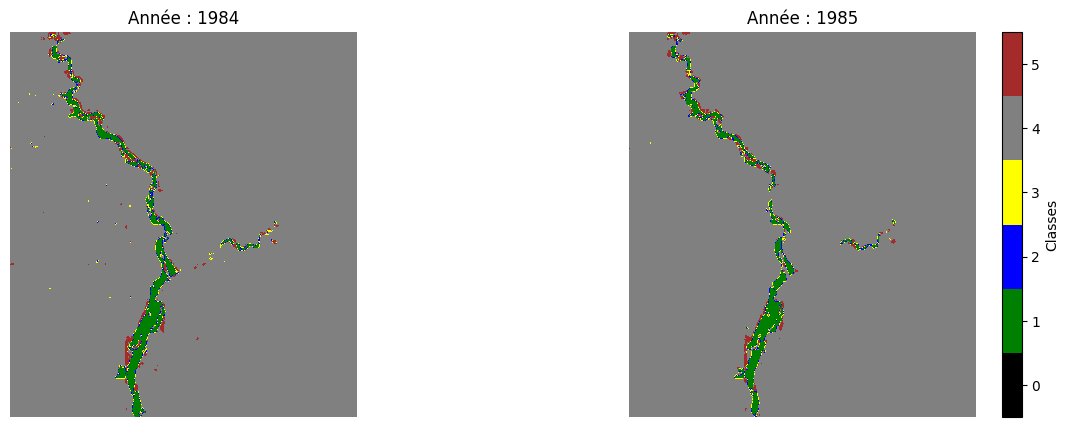

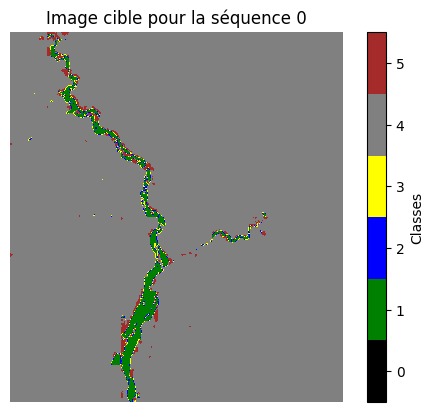


Affichage de la séquence 1 et de sa cible :
Séquence 0 : Années [1984 1985]


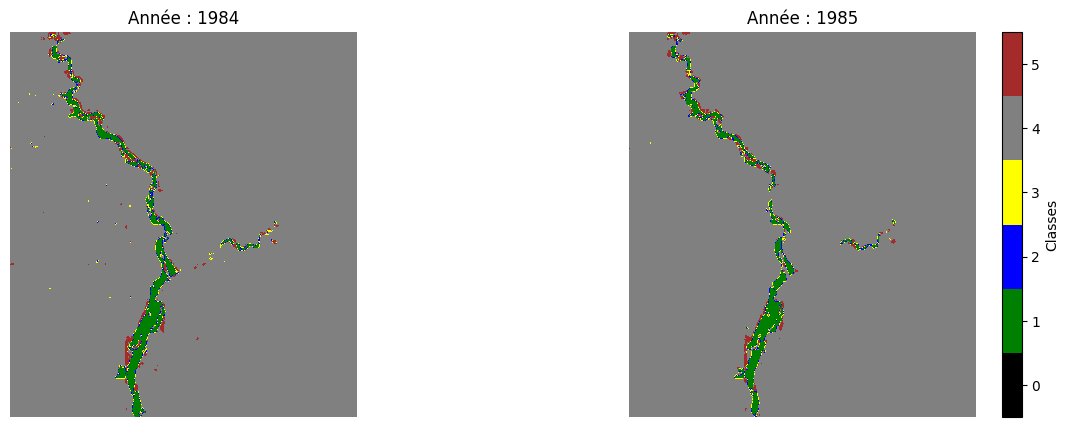

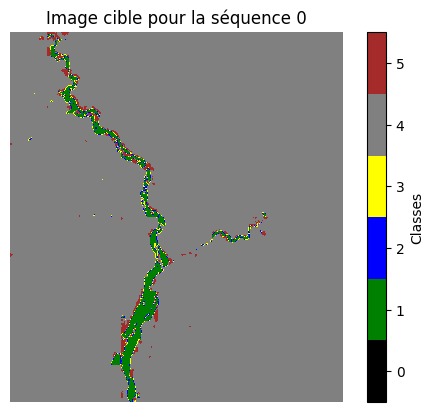


Affichage de la séquence 2 et de sa cible :
Séquence 1 : Années [1985 1986]


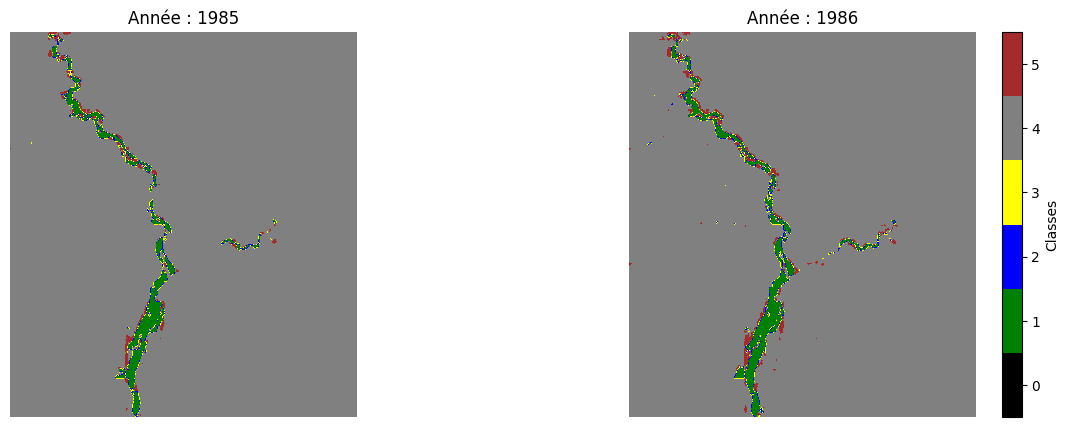

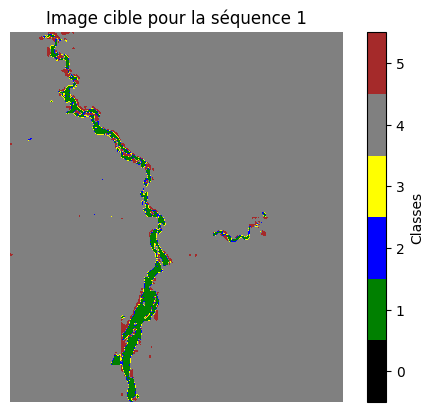


Affichage de la séquence 3 et de sa cible :
Séquence 2 : Années [1986 1987]


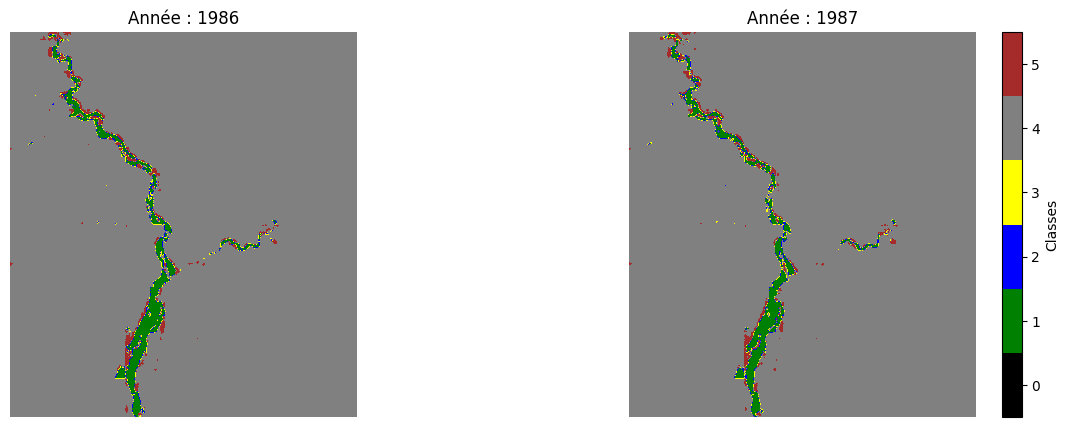

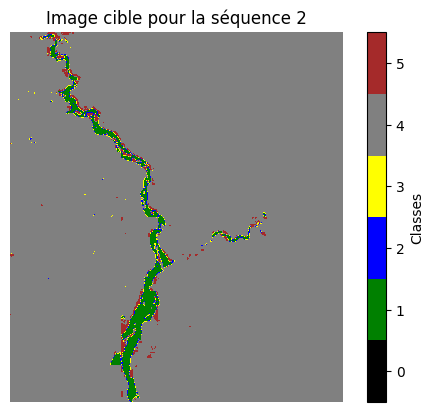


Affichage de la séquence 4 et de sa cible :
Séquence 3 : Années [1987 1988]


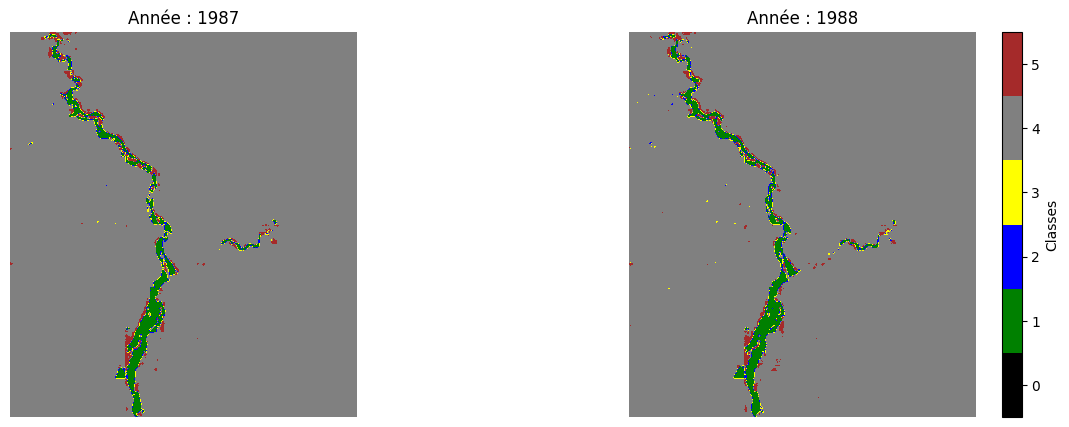

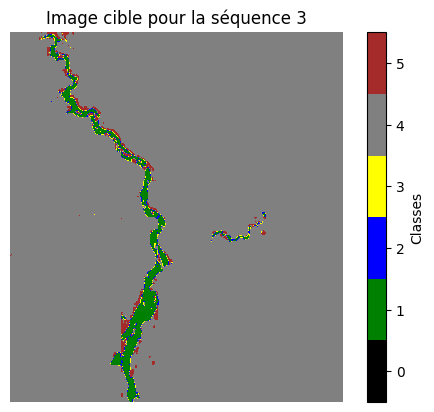

In [ ]:
# Définir les couleurs pour les classes
colors = ['black', 'green', 'blue', 'yellow', 'gray', 'brown']
echelle = ['Vide', 'Oasis', 'Eau', 'Sable', 'Montagne', 'Habitation']
ticks = [0, 1, 2, 3, 4, 5]

# Créer une colormap personnalisée
cmap = ListedColormap(colors)

# Fonction pour afficher une séquence d'images

def display_sequence(X, years, sequence_index):
    print(f"Séquence {sequence_index} : Années {years[sequence_index:sequence_index + X.shape[1]]}")
    sequence = X[sequence_index]
    plt.figure(figsize=(15, 5))
    for i, img in enumerate(sequence):
        plt.subplot(1, X.shape[1], i + 1)
        plt.imshow(img, cmap=cmap, vmin=0, vmax=len(colors) - 1)
        plt.title(f"Année : {years[sequence_index + i]}")
        plt.axis('off')
    plt.colorbar(boundaries=np.arange(len(colors) + 1) - 0.5, ticks=ticks, label='Classes')
    plt.show()

# Fonction pour afficher l'image cible associée à une séquence
def display_target(y, sequence_index):
    target_image = y[sequence_index]
    plt.imshow(target_image, cmap=cmap, vmin=0, vmax=len(colors) - 1)
    plt.title(f"Image cible pour la séquence {sequence_index}")
    plt.axis('off')
    plt.colorbar(boundaries=np.arange(len(colors) + 1) - 0.5, ticks=ticks, label='Classes')
    plt.show()

# Vérification : Afficher la première séquence et sa cible
display_sequence(X, years, sequence_index=0)
display_target(y, sequence_index=0)

# Vérification : Afficher plusieurs séquences et leurs cibles
def display_multiple_sequences(X, y, years, num_sequences=3):
    for seq_idx in range(num_sequences):
        print(f"\nAffichage de la séquence {seq_idx + 1} et de sa cible :")
        display_sequence(X, years, sequence_index=seq_idx)
        display_target(y, sequence_index=seq_idx)

# Afficher les 3 premières séquences et leurs cibles
display_multiple_sequences(X, y, years, num_sequences=4)


Creation des dataset de training et de validation

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, shuffle=False)

# Afficher les tailles des ensembles
print(f"Ensemble d'entraînement : X_train.shape = {X_train.shape}, y_train.shape = {y_train.shape}")
print(f"Ensemble de test : X_test.shape = {X_test.shape}, y_test.shape = {y_test.shape}")


Ensemble d'entraînement : X_train.shape = (25, 2, 1040, 936), y_train.shape = (25, 1040, 936)
Ensemble de test : X_test.shape = (11, 2, 1040, 936), y_test.shape = (11, 1040, 936)


In [ ]:
X_train = np.expand_dims(X_train, axis=-1)
y_train = np.expand_dims(y_train, axis=-1)

X_test = np.expand_dims(X_test, axis=-1)
y_test = np.expand_dims(y_test, axis=-1)

# Vérification des nouvelles formes
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (25, 2, 1040, 936, 1)
y_train shape: (25, 1040, 936, 1)
X_test shape: (11, 2, 1040, 936, 1)
y_test shape: (11, 1040, 936, 1)


##CREATION MODELE

Fonction loss personnalisée avec des poids pour compenser le déséquilibre des classes

In [ ]:
def weighted_loss(y_true, y_pred, class_weights={0: 1., 1: 3., 2: 3., 3: 1., 4: 1., 5: 3.}):
    """
    Fonction de perte personnalisée avec pondération des classes.
    y_true : étiquettes réelles (ground truth)
    y_pred : prédictions du modèle
    class_weights : dictionnaire contenant les poids des classes
    """
    # Convertir les étiquettes et les prédictions en entiers pour le calcul de la perte
    y_true = tf.cast(y_true, tf.int32)  # Assurer que y_true est en int32
    y_pred = tf.cast(y_pred, tf.float32)
    # Calculer la perte de type sparse_categorical_crossentropy
    loss = tf.keras.losses.sparse_categorical_crossentropy(y_true, y_pred)

    # Convertir class_weights en un tensor de TensorFlow avec les poids des classes
    class_weights_tensor = tf.convert_to_tensor(list(class_weights.values()), dtype=tf.float32)

    # Appliquer les poids des classes à chaque pixel
    class_weights_tensor = tf.gather(class_weights_tensor, y_true)  # Récupère le poids correspondant à chaque classe
    class_weights_tensor = tf.reshape(class_weights_tensor, tf.shape(loss))
    weighted_loss = loss * class_weights_tensor  # Appliquer le poids aux pertes pour chaque pixel

    # Retourner la moyenne de la perte pondérée
    return tf.reduce_mean(weighted_loss)

In [ ]:
# Création du modèle avec MeanIoU et classes à ignorer
def build_model(input_shape, num_classes=7):
    model = Sequential()

    # Première couche ConvLSTM2D avec HeNormal
    model.add(ConvLSTM2D(filters=32, kernel_size=(5, 5), padding='same', return_sequences=True, input_shape=input_shape,
                         kernel_initializer=HeNormal()))  # HeNormal initializer pour les poids
    model.add(MaxPooling3D(pool_size=(1, 2, 2)))  # Réduction de la taille de l'image

    # Deuxième couche ConvLSTM2D avec HeNormal
    model.add(ConvLSTM2D(filters=64, kernel_size=(5, 5), padding='same', return_sequences=True,
                         kernel_initializer=HeNormal()))  # HeNormal initializer pour les poids
    model.add(MaxPooling3D(pool_size=(1, 2, 2)))  # Réduction de la taille de l'image

    # Couches ConvLSTM2D pour capturer les relations spatiales et temporelles
    model.add(ConvLSTM2D(filters=128, kernel_size=(5, 5), padding='same', return_sequences=False,
                         kernel_initializer=HeNormal()))  # HeNormal initializer pour les poids
    model.add(UpSampling2D(size=(4, 4)))  # Upsampling par un facteur de 4

    # Couches convolutionnelles pour prédire les classes de chaque pixel avec HeNormal
    model.add(Conv2D(filters=num_classes, kernel_size=(5, 5), activation='softmax', padding='same',
                     kernel_initializer=HeNormal()))  # num_classes classes de sortie

    class_weights = {0: 1., 1: 3., 2: 3., 3: 1., 4: 1., 5: 3.}  # Pondération des classes

    # Optimizer avec taux d'apprentissage faible
    optimizer = Adam(learning_rate=0.0001)

    # Ajouter la métrique MeanIoU (Mean Intersection over Union) avec classes à ignorer (0, 3, 4)
    mean_iou = tf.keras.metrics.MeanIoU(num_classes=num_classes, ignore_class=[4], sparse_y_true=True, sparse_y_pred=False, name='mean_iou')

    # Compiler le modèle avec la métrique MeanIoU
    model.compile(optimizer=optimizer,
                  loss=lambda y_true, y_pred: weighted_loss(y_true, y_pred, class_weights={0: 1., 1: 3., 2: 3., 3: 1., 4: 1., 5: 3.}),
                  metrics=['accuracy', mean_iou])
    return model


# Définir la forme d'entrée (nombre de séquences, hauteur, largeur, nombre de canaux)
input_shape = (2, 1040, 936, 1)#X_train.shape[1:]  # (5, 1040, 936, 1)

# Construire le modèle
modele = build_model(input_shape, num_classes=7)

# Résumé du modèle
modele.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv_lstm2d_3 (ConvLSTM2D)           │ (None, 2, 1040, 936, 32)    │         105,728 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_2 (MaxPooling3D)       │ (None, 2, 520, 468, 32)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_4 (ConvLSTM2D)           │ (None, 2, 520, 468, 64)     │         614,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling3d_3 (MaxPooling3D)       │ (None, 2, 260, 234, 64)     │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv_lstm2d_5 (ConvLSTM2D)           │ (None, 260, 234, 128)       │       2,458,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ up_sampling2d_1 (UpSampling2D)       │ (None, 1040, 936, 128)      │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 1040, 936, 7)        │          22,407 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,200,903 (12.21 MB)

 Trainable params: 3,200,903 (12.21 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Entraîner le modèle ConvLSTM avec les ensembles train et validation
history = modele.fit(
    X_train, y_train,  # Données d'entraînement
    epochs=40,         # Nombre d'époques d'entraînement
    batch_size=1,      # Taille du lot pour l'entraînement
    validation_data=(X_test, y_test),  # Données de validation
    verbose=1          # Affichage des métriques pendant l'entraînement
)


Epoch 1/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 63s 2s/step - accuracy: 0.5936 - loss: 1.7072 - mean_iou: 0.0032 - val_accuracy: 0.9009 - val_loss: 0.7516 - val_mean_iou: 9.5411e-07
Epoch 2/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9295 - loss: 0.7798 - mean_iou: 0.0174 - val_accuracy: 0.9189 - val_loss: 0.6267 - val_mean_iou: 0.1085
Epoch 3/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 50s 2s/step - accuracy: 0.9519 - loss: 0.5584 - mean_iou: 0.0598 - val_accuracy: 0.9191 - val_loss: 0.6190 - val_mean_iou: 0.1315
Epoch 4/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.9300 - loss: 0.6101 - mean_iou: 0.0936 - val_accuracy: 0.9204 - val_loss: 0.6017 - val_mean_iou: 0.1293
Epoch 5/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 77s 2s/step - accuracy: 0.9728 - loss: 0.3223 - mean_iou: 0.1044 - val_accuracy: 0.9136 - val_loss: 0.6206 - val_mean_iou: 0.1327
Epoch 6/40
25/25 ━━━━━━━━━━━━━━━━━━━━ 82s 2s/step - accuracy: 0.9354 - loss: 0.6320 - mean_iou: 0.0983 - val_accuracy: 0.9209 - val_loss: 0.5826 - val_mean_

# Evaluation

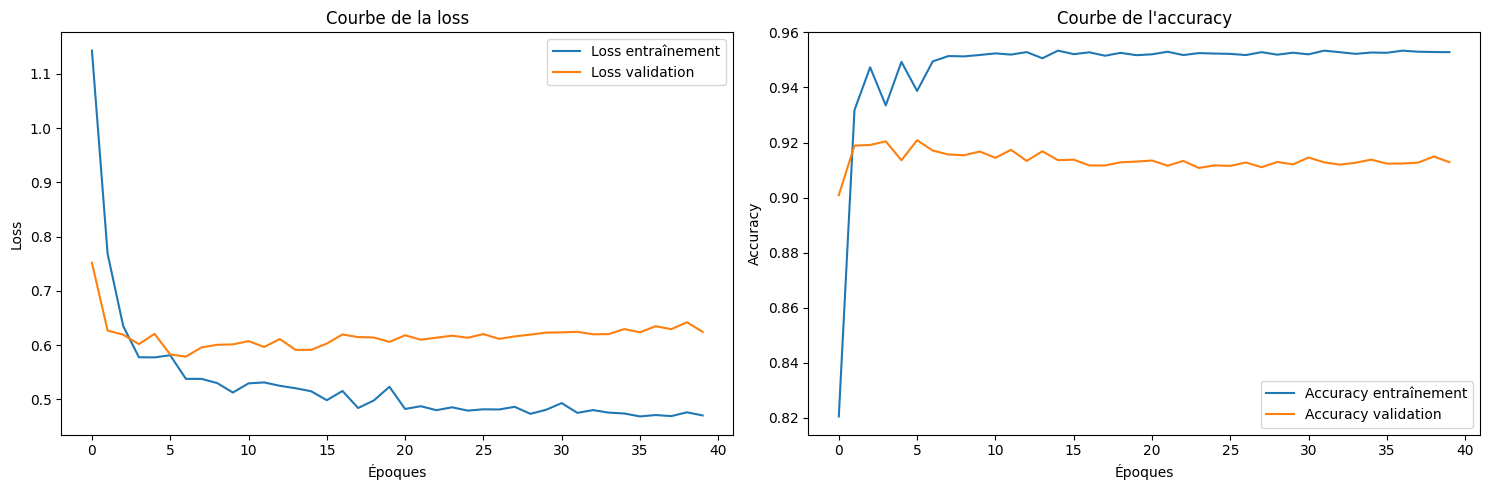

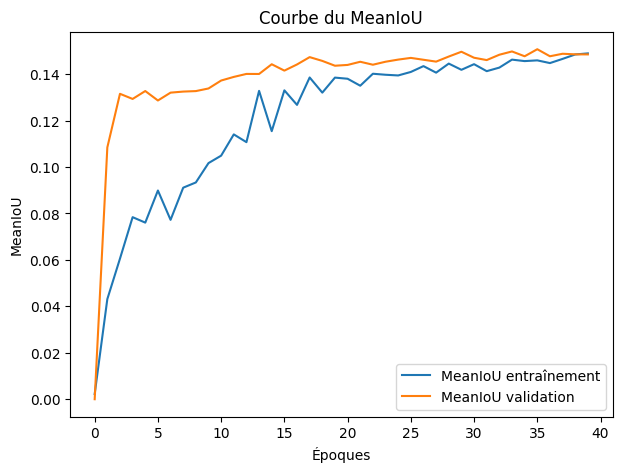

In [ ]:
# Fonction pour afficher les courbes d'entraînement
def plot_training_history(history):
    # Afficher les courbes de loss et d'accuracy
    plt.figure(figsize=(15, 5))

    # Courbe de la loss
    plt.subplot(1, 2, 1)
    plt.plot(history.history['loss'], label='Loss entraînement')
    plt.plot(history.history['val_loss'], label='Loss validation')
    plt.title('Courbe de la loss')
    plt.xlabel('Époques')
    plt.ylabel('Loss')
    plt.legend()

    # Courbe de l'accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history.history['accuracy'], label='Accuracy entraînement')
    plt.plot(history.history['val_accuracy'], label='Accuracy validation')
    plt.title('Courbe de l\'accuracy')
    plt.xlabel('Époques')
    plt.ylabel('Accuracy')
    plt.legend()

    plt.tight_layout()
    plt.show()

    # Afficher MeanIoU s'il est présent dans les métriques
    if 'mean_iou' in history.history and 'val_mean_iou' in history.history:
        plt.figure(figsize=(7, 5))
        plt.plot(history.history['mean_iou'], label='MeanIoU entraînement')
        plt.plot(history.history['val_mean_iou'], label='MeanIoU validation')
        plt.title('Courbe du MeanIoU')
        plt.xlabel('Époques')
        plt.ylabel('MeanIoU')
        plt.legend()
        plt.show()
# Afficher les courbes de loss, accuracy, et MeanIoU
plot_training_history(history)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


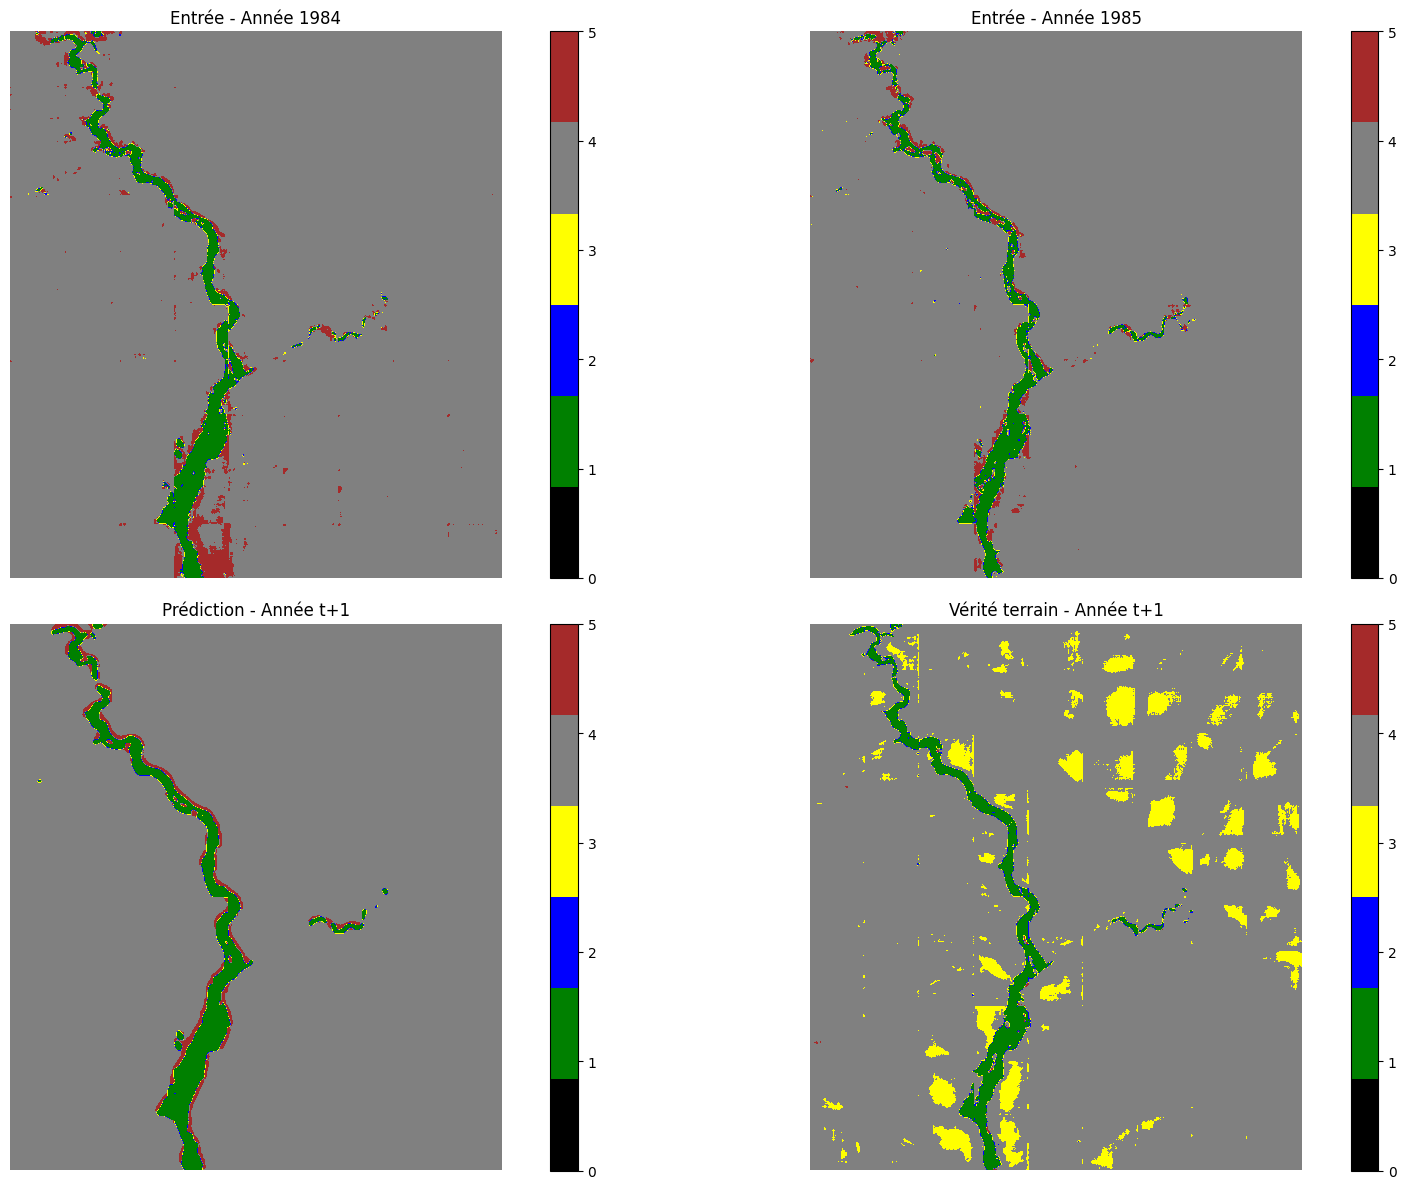

In [ ]:
# Définir les couleurs et classes
colors = ['black', 'green', 'blue', 'yellow', 'gray', 'brown']
echelle = ['Vide', 'Oasis', 'Eau', 'Sable', 'Montagne', 'Habitation']
ticks = [0, 1, 2, 3, 4, 5]
cmap = ListedColormap(colors)

# Prédiction avec le modèle
predictions = modele.predict(X_test)  # Prédire les résultats pour les données de test

# Choisir un indice pour visualiser une séquence spécifique
index = 0  # Indice de la séquence (exemple : première séquence)

# Prendre la séquence d'entrée, la prédiction, et la vérité terrain
input_images = X_test[index]  # Les 5 images d'entrée pour l'indice sélectionné
predicted_image = predictions[index].argmax(axis=-1)  # La prédiction du modèle pour t+1
true_image = y_test[index]  # L'image réelle pour t+1

# Affichage des images
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Afficher les 2 images d'entrée
for i in range(2):
    im = axes[0, i % 2].imshow(input_images[i], cmap=cmap, vmin=0, vmax=len(colors) - 1)  # Image d'entrée
    axes[0, i % 2].set_title(f"Entrée - Année {years[index + i]}")
    axes[0, i % 2].axis('off')
    fig.colorbar(im, ax=axes[0, i % 5])  # Ajouter une échelle des couleurs

# Afficher l'image prédite
im_pred = axes[1, 0].imshow(predicted_image, cmap=cmap, vmin=0, vmax=len(colors) - 1)  # Image prédite
axes[1, 0].set_title(f"Prédiction - Année t+1")
axes[1, 0].axis('off')
fig.colorbar(im_pred, ax=axes[1, 0])

# Afficher l'image réelle
im_true = axes[1, 1].imshow(true_image, cmap=cmap, vmin=0, vmax=len(colors) - 1)  # Vérité terrain
axes[1, 1].set_title(f"Vérité terrain - Année t+1")
axes[1, 1].axis('off')
fig.colorbar(im_true, ax=axes[1, 1])


# Affichage final
plt.tight_layout()
plt.show()


# Prediction année 2050


In [ ]:
annee_à_predire = 2050

In [ ]:
batch_time = 3

In [ ]:
def load_images_with_years(data_folder):
    data = []

    # Charger les images pour chaque année en fonction des noms de fichiers
    for file_name in os.listdir(data_folder):
        if file_name.endswith(".tif.npy"):  # Assurer que ce soit bien un fichier .npy
            year = int(file_name.split('_')[-1].split('.')[0])  # Extraire l'année du nom de fichier
            image_path = os.path.join(data_folder, file_name)
            image = np.load(image_path)
            data.append((year, image))  # Stocker un tuple (année, image)

    # Trier les tuples par année
    data.sort(key=lambda x: x[0])  # Tri basé sur l'année

    return data

In [ ]:
data_folder_p = data_folder

In [ ]:
images_with_years = load_images_with_years(data_folder_p)

In [ ]:
nb_pred_to_do = annee_à_predire - max(years)
first_batch_years = heapq.nlargest(batch_time, years)
tri = first_batch_years.sort()
dernieres_annees = heapq.nlargest(batch_time, images_with_years, key=lambda x: x[0])

In [ ]:
dernieres_annees = heapq.nlargest(batch_time, images_with_years, key=lambda x: x[0])
dernieres_annees_triees = sorted(dernieres_annees, key=lambda x: x[0])
dernieres_images = [np.expand_dims(image,axis = -1) for _, image in dernieres_annees_triees]
sequence = np.stack(dernieres_images)
sequence = np.expand_dims(sequence, axis=0)  # Forme : (1, seq_length, height, width, channels)
print(sequence.shape)

(1, 3, 1040, 936, 1)


Fonction pour prédire l'année suivante et se servir de la prédiction pour faire celle d'après

In [ ]:
def prediction_annee(nb_prediction,dataset,modele):
  assert dataset.shape[1] == batch_time
  prediction =[]
  current_sequence = dataset.copy()
  for i in range(nb_prediction):
    next_image = modele.predict(current_sequence)
    next_image = np.argmax(next_image, axis=-1)  # Appliquer argmax sur la dimension des classes (dimension 3)
    prediction.append(next_image)
    next_image = np.expand_dims(next_image, axis=-1)  # Ajouter la dimension des canaux si nécessaire
    print("Prediction n°",i)
    current_sequence = np.concatenate([
            current_sequence[:, 1:],  # Garder les deux dernières images de la séquence
            np.expand_dims(next_image, axis=0)  # Ajouter la nouvelle prédiction
        ], axis=1)
  return prediction

In [ ]:
prediction = prediction_annee(nb_pred_to_do,sequence,modele)

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Prediction n° 0
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Prediction n° 1
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Prediction n° 2
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction n° 3
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step
Prediction n° 4
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Prediction n° 5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step
Prediction n° 6
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Prediction n° 7
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Prediction n° 8
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
Prediction n° 9
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Prediction n° 10
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction n° 11
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction n° 12
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction n° 13
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
Prediction n° 14
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step
Prediction n° 15
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
Prediction n° 16
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Prediction n° 17
1/1 ━━━━━━━━━━━━━━━━━━

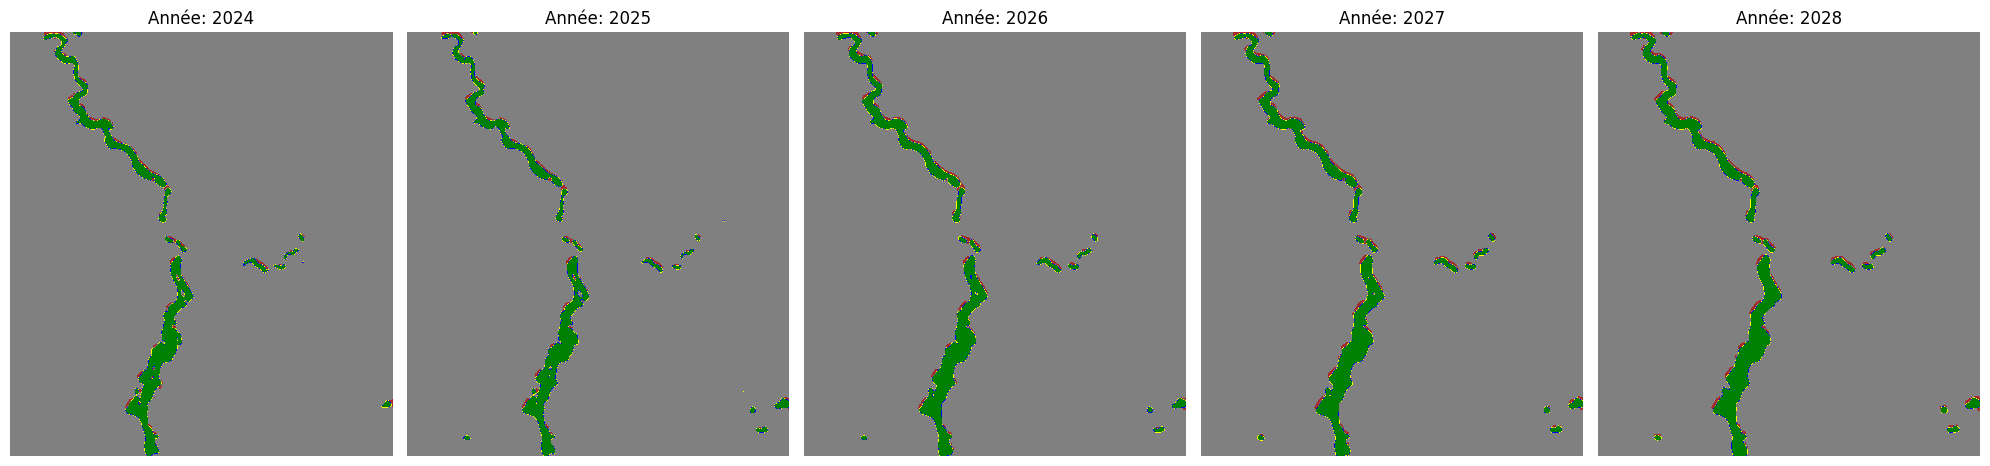

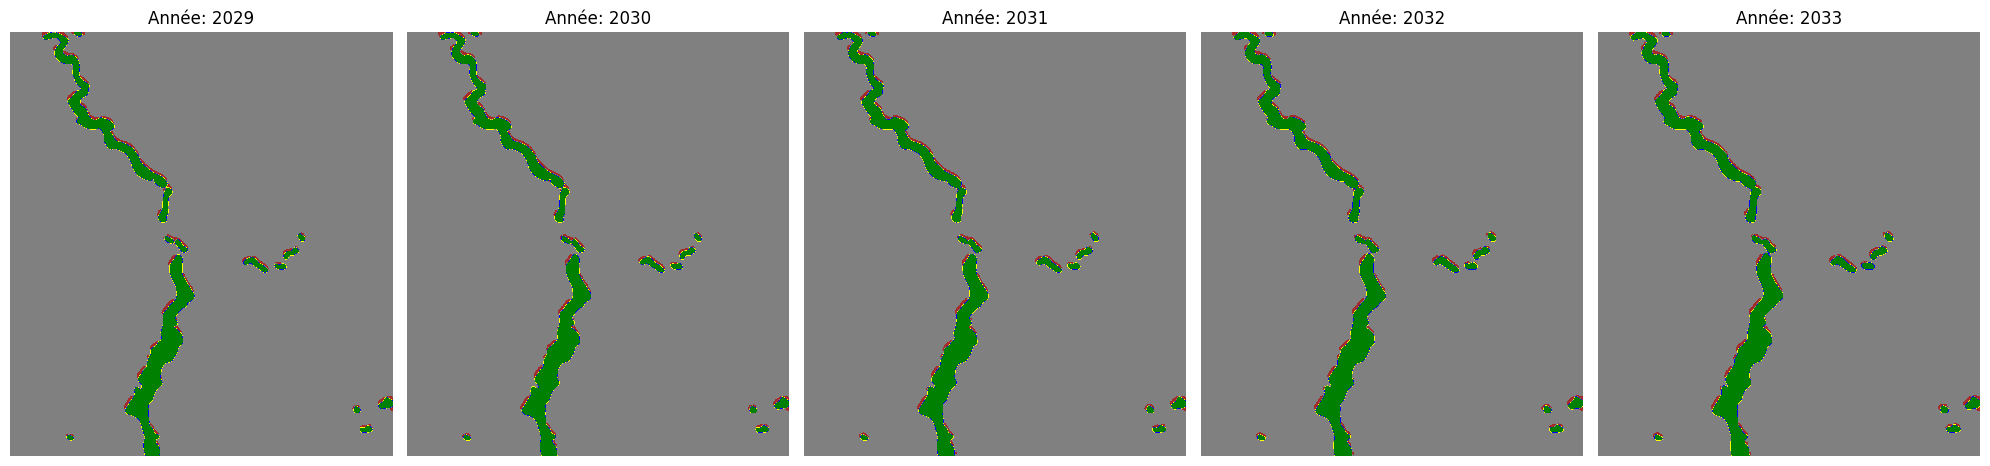

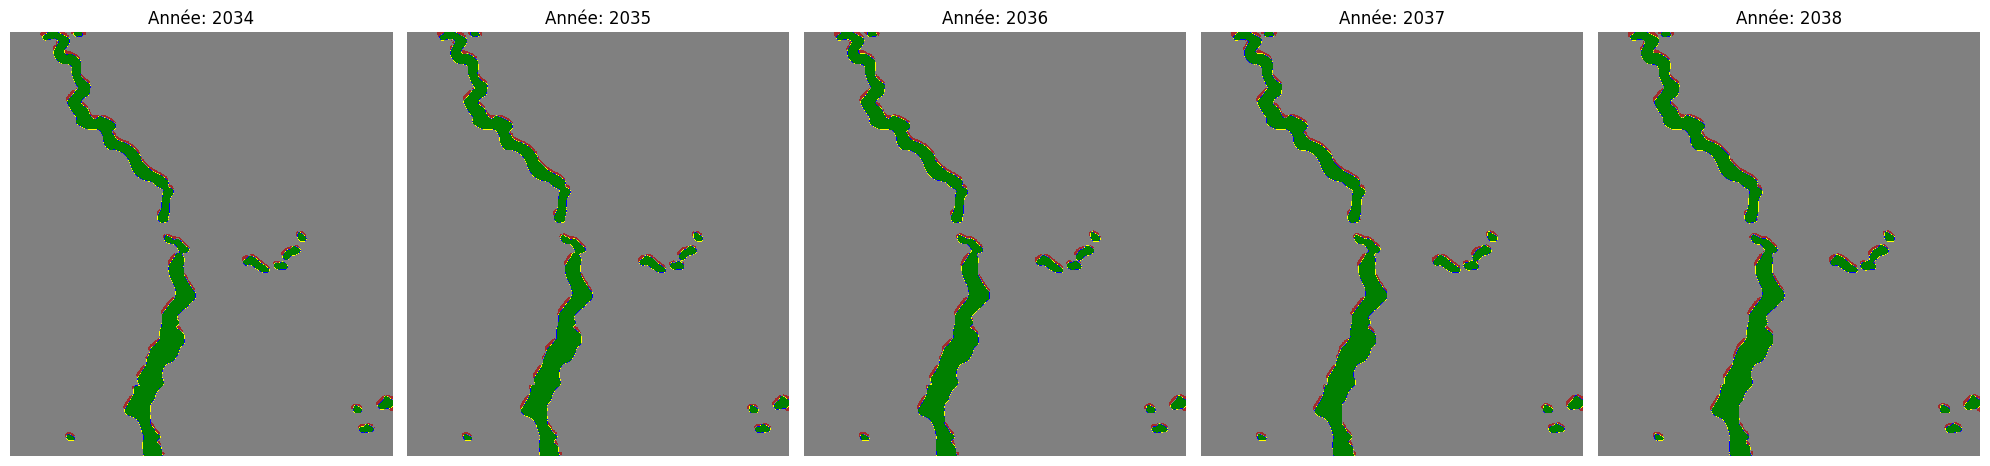

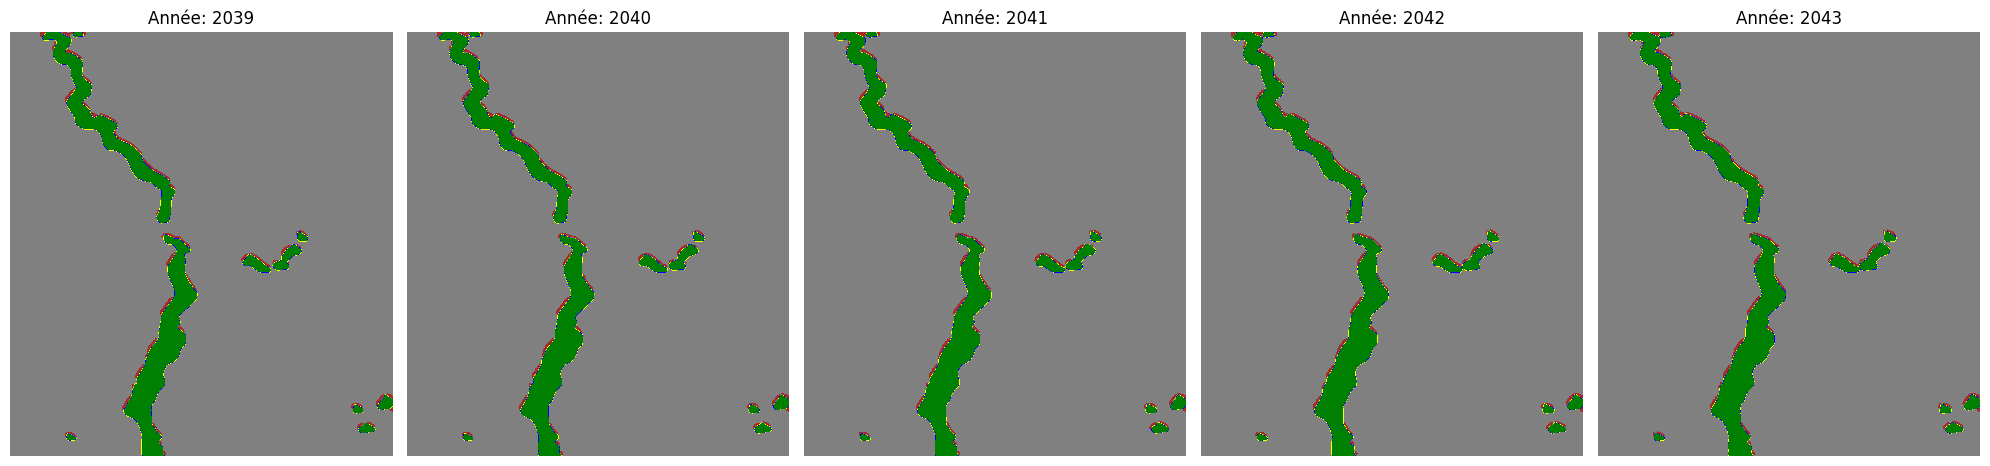

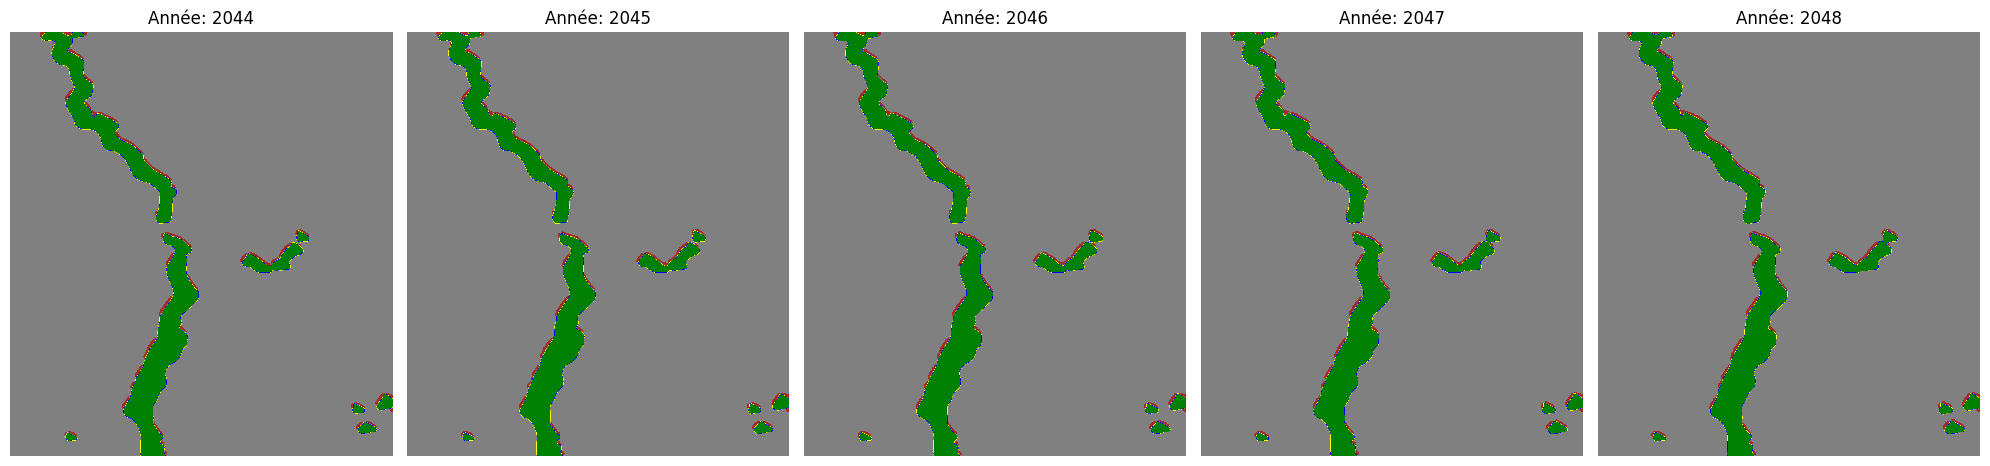

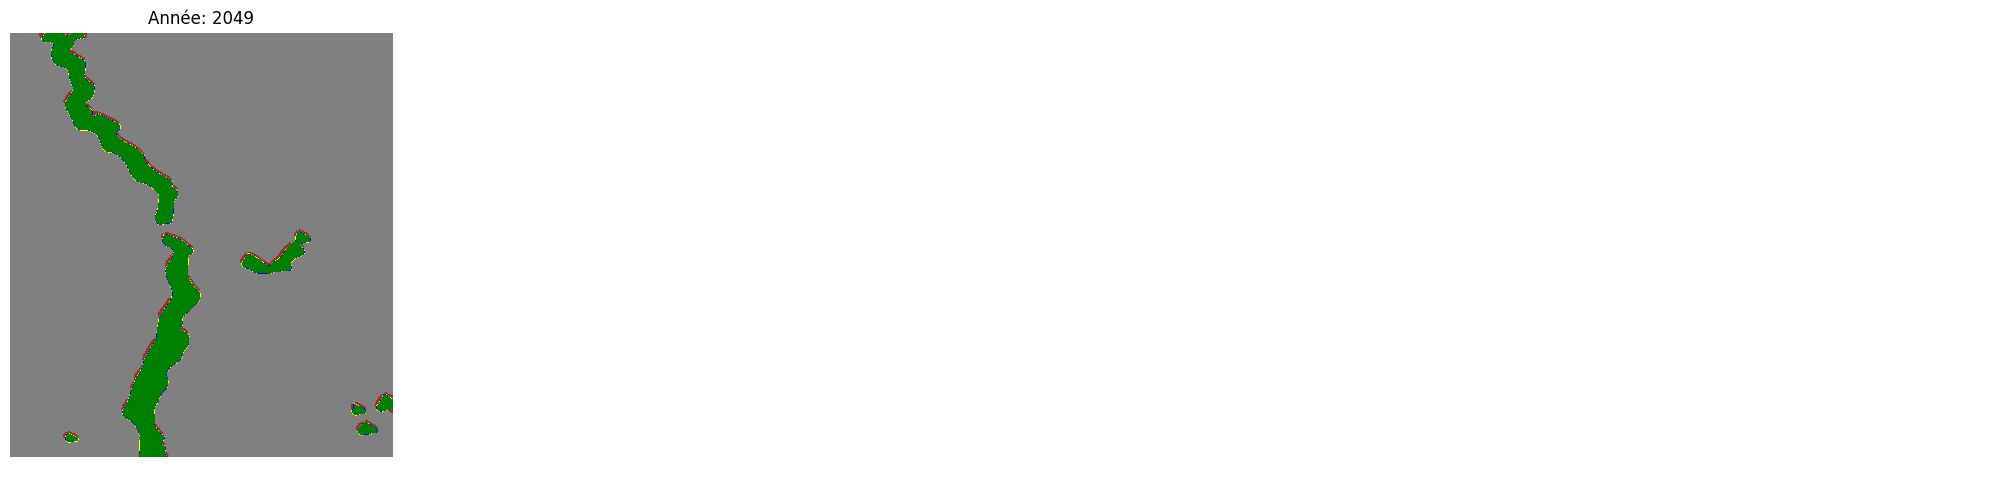

In [ ]:
# Définition de la carte des couleurs (colormap)
colors = ['black', 'green', 'blue', 'yellow', 'gray', 'brown']
echelle = ['Vide', 'Oasis', 'Eau', 'Sable', 'Montagne', 'Habitation']
ticks = [0, 1, 2, 3, 4, 5]
cmap = ListedColormap(colors)


def display_predictions(predictions, initial_year, num_predictions):
    """
    Affiche les prédictions dans des figures avec 5 images par figure et leur année respective en titre.

    """
    # Nombre d'images par figure
    images_per_figure = 5

    # Calculer le nombre de figures nécessaires
    num_figures = (num_predictions // images_per_figure) + (1 if num_predictions % images_per_figure != 0 else 0)

    for fig_idx in range(num_figures):
        # Créer une nouvelle figure
        fig, axes = plt.subplots(1, images_per_figure, figsize=(20, 5))

        # Calculer les indices des prédictions à afficher dans cette figure
        start_idx = fig_idx * images_per_figure
        end_idx = min(start_idx + images_per_figure, num_predictions)

        for i, ax in enumerate(axes):
            # Si nous avons encore des images à afficher
            if start_idx + i < end_idx:
                # Calculer l'année associée à cette prédiction
                pred_year = initial_year + start_idx + i

                # S'assurer que l'image a la bonne forme (1040, 936)
                pred_image = predictions[start_idx + i].squeeze()  # Supprime la dimension de taille 1

                # Afficher l'image et le titre avec l'année
                ax.imshow(pred_image, cmap=cmap, vmin=0, vmax=5)
                ax.set_title(f"Année: {pred_year}")
                ax.axis('off')  # Masquer les axes

            else:
                # Si nous n'avons plus d'images à afficher dans cette figure, masquer l'axe
                ax.axis('off')

        # Afficher la figure
        plt.tight_layout()
        plt.show()

# Appeler la fonction pour afficher les prédictions
display_predictions(prediction, max(years), len(prediction))


## ANALYSE DU NOMBRE DE PIXEL PAR CLASSE AU FIL DU TEMPS

La classe "Sahara" représente le sable et non les terres arides qui sont dans la classe "Roche". Etant surreprésentée, cette dernière classe n'apparait pas sur le graphe, d'où la domination de la végétation.

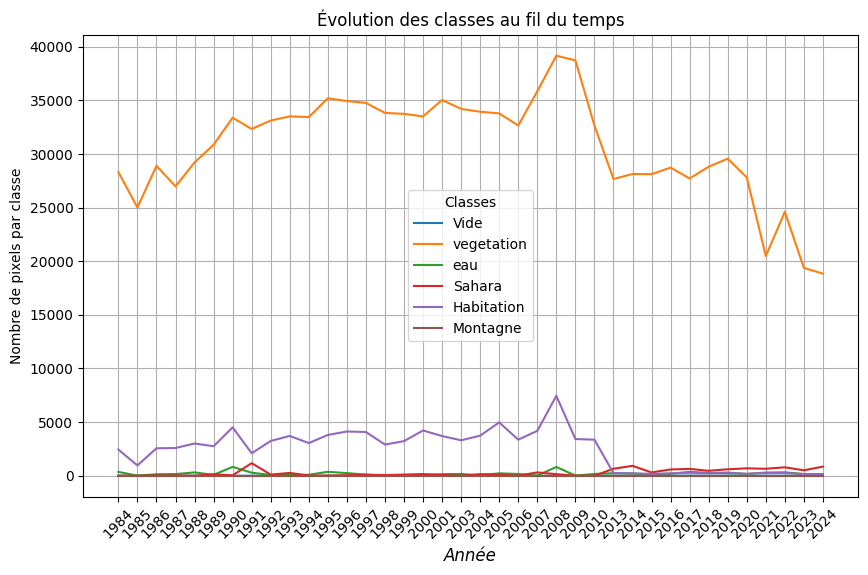

In [ ]:
# Initialiser les données pour les courbes
years = []
class_counts = {name: [] for name in class_names.values()}  # Dictionnaire vide pour chaque classe

# Parcourir les images et compter les classes
for reconstructed_image,year in pred_date:
    years.append(year)  # Ajouter l'année
    unique_values, counts = np.unique(reconstructed_image, return_counts=True)

    # Initialiser tous les comptes à 0 pour cette année
    current_counts = {name: 0 for name in class_names.values()}

    # Remplir les comptes réels
    for value, count in zip(unique_values, counts):
        class_name = class_names.get(value, f"Classe inconnue ({value})")
        current_counts[class_name] = count

    # Ajouter les comptes de cette année au dictionnaire global
    for name, count in current_counts.items():
        class_counts[name].append(count)

# Tracer les courbes
plt.figure(figsize=(10, 6))

for class_name, counts in class_counts.items():
    if class_name == "Roche":  # Ignorer la classe "champ"
        continue
    plt.plot(years, counts, label=class_name)

# Ajouter des labels et une légende
plt.title("Évolution des classes au fil du temps")
plt.xlabel("Année", fontsize=12, fontstyle='italic')
plt.ylabel("Nombre de pixels par classe")
plt.legend(title="Classes")
plt.grid(True)
plt.xticks(rotation=45)
plt.show()
